# Notebook 06 — SHAP Explainability & Retention Insight
### Global churn drivers, local high-value target explanations, validation vs actual churn reasons

In [1]:
 
# ===== CELL 1: imports + config =====
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
 
try:
    import shap
except ImportError:
    os.system("pip install shap -q")
    import shap
 
MODEL_DIR = "/kaggle/input/notebooks/mumtaheenabinteahmed/ieee-csde-2"   # NB02 models
SPLIT_DIR = "/kaggle/input/notebooks/mumtaheenabinteahmed/ieee-csde-1"   # NB01 splits
OUT_DIR   = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)
 
CHAMP     = {"maven": "LGBM", "cell": "XGB"}
MONEY_COL = {"maven": "Monthly Charge", "cell": "MonthlyRevenue"}
H, MARGIN = 12, 0.30
 

In [2]:

# ===== CELL 2: helper — load model, transform test, get SHAP values =====
def get_shap(ds):
    pipe = joblib.load(f"{MODEL_DIR}/model_{ds}_{CHAMP[ds]}.joblib")
    pre  = pipe.named_steps["pre"]
    clf  = pipe.named_steps["clf"]
 
    test = pd.read_csv(f"{SPLIT_DIR}/{ds}_test.csv")
    y    = test["target"].values
    X    = test.drop(columns=["target"])
    Xt   = pre.transform(X)
    feat = list(pre.get_feature_names_out())
    # tidy names: drop 'num__' / 'cat__' prefixes
    feat = [f.split("__", 1)[-1] for f in feat]
 
    p    = clf.predict_proba(Xt)[:, 1]
 
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(Xt)
    if isinstance(sv, list):            # some sklearn wrappers -> [class0, class1]
        sv = sv[1]
    elif np.ndim(sv) == 3:              # (n, feat, class)
        sv = sv[:, :, 1]
    sv = np.asarray(sv)
    return dict(ds=ds, Xt=Xt, feat=feat, sv=sv, y=y, p=p, money=X[MONEY_COL[ds]].values)
 

In [3]:

# ===== CELL 3: global importance + plots =====
def global_importance(S, topk=15):
    ds, feat, sv = S["ds"], S["feat"], S["sv"]
    imp = np.abs(sv).mean(axis=0)
    order = np.argsort(imp)[::-1]
    tbl = pd.DataFrame({"feature": [feat[i] for i in order],
                        "mean_abs_shap": imp[order]}).round(5)
    tbl.head(topk).to_csv(f"{OUT_DIR}/shap_importance_{ds}.csv", index=False)
    print(f"\n===== {ds.upper()} ({CHAMP[ds]}) — top {topk} churn drivers =====")
    print(tbl.head(topk).to_string(index=False))
 
    # bar plot
    top = tbl.head(topk)[::-1]
    plt.figure(figsize=(7, 5))
    plt.barh(top["feature"], top["mean_abs_shap"])
    plt.xlabel("mean |SHAP value|"); plt.title(f"{ds} — global churn drivers ({CHAMP[ds]})")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_shap_bar_{ds}.png", dpi=200); plt.show()
 
    # beeswarm (sample for readability)
    idx = np.random.RandomState(42).choice(len(sv), min(2000, len(sv)), replace=False)
    plt.figure()
    shap.summary_plot(sv[idx], S["Xt"][idx], feature_names=feat, show=False, max_display=topk)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_shap_beeswarm_{ds}.png", dpi=200,
                                    bbox_inches="tight"); plt.show()
    return tbl


In [4]:

# ===== CELL 4: local explanation for a high-value targeted customer =====
def local_explanation(S, topk=10):
    ds, feat, sv = S["ds"], S["feat"], S["sv"]
    m = S["money"].astype(float)
    m = np.where(np.isnan(m), np.nanmedian(m), m)   # fill NaN before CLV
    clv = np.maximum(m, 0) * H * MARGIN
    # "high-value target" = high CLV AND high predicted churn prob
    score = clv * S["p"]
    i = int(np.argmax(score))
    contrib = sv[i]
    order = np.argsort(np.abs(contrib))[::-1][:topk]
    names = [feat[j] for j in order][::-1]
    vals  = contrib[order][::-1]
    colors = ["#d62728" if v > 0 else "#1f77b4" for v in vals]  # red=push to churn
 
    plt.figure(figsize=(7, 5))
    plt.barh(names, vals, color=colors)
    plt.axvline(0, color="k", lw=0.6)
    plt.xlabel("SHAP contribution (red = pushes toward churn)")
    plt.title(f"{ds} — why customer #{i} is a high-value retention target\n"
              f"(CLV≈{clv[i]:.0f}, p(churn)={S['p'][i]:.2f})")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_shap_local_{ds}.png", dpi=200); plt.show()
    print(f"{ds}: local example customer #{i} | CLV≈{clv[i]:.0f} | p={S['p'][i]:.3f} | "
          f"actual churn={S['y'][i]}")
 


===== MAVEN (LGBM) — top 15 churn drivers =====
                          feature  mean_abs_shap
          Contract_Month-to-Month        1.35850
              Number of Referrals        1.19436
                 Tenure in Months        1.07651
             Number of Dependents        0.87847
                   Monthly Charge        0.73662
                Contract_Two Year        0.55626
                              Age        0.30243
                    Total Revenue        0.23703
      Total Long Distance Charges        0.23553
                    Total Charges        0.23202
          Premium Tech Support_No        0.23095
               Online Security_No        0.21976
          Avg Monthly GB Download        0.18853
Avg Monthly Long Distance Charges        0.18281
       Payment Method_Credit Card        0.12969


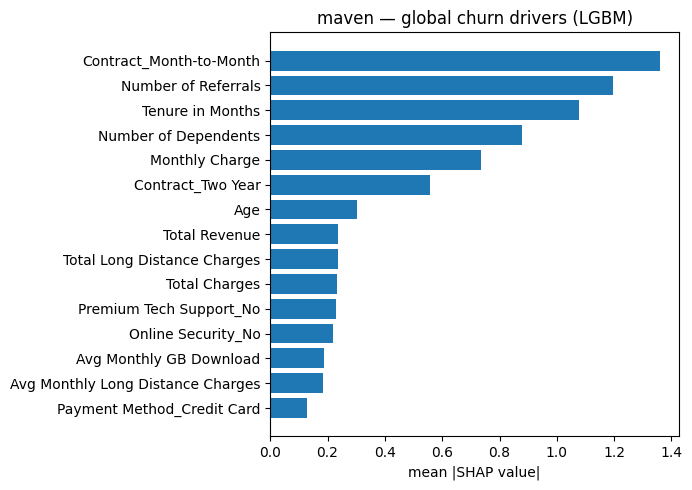

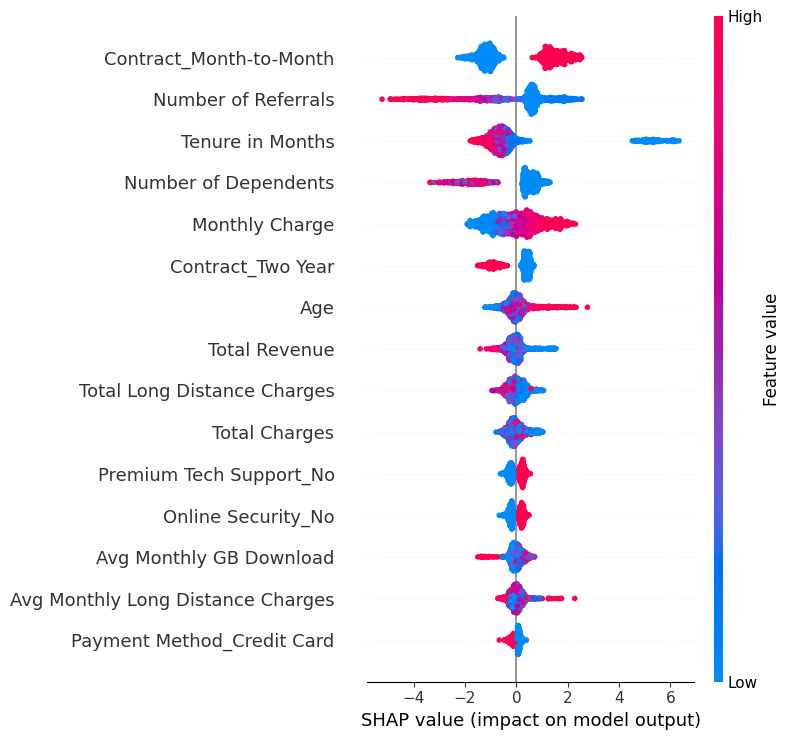

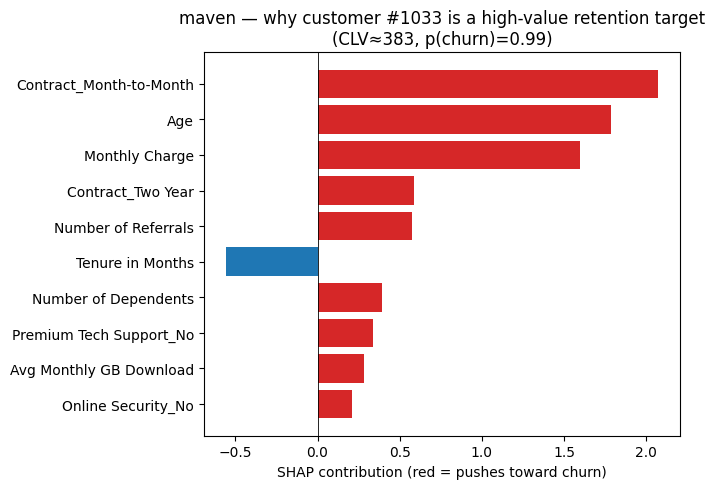

maven: local example customer #1033 | CLV≈383 | p=0.993 | actual churn=1

===== CELL (XGB) — top 15 churn drivers =====
             feature  mean_abs_shap
CurrentEquipmentDays        0.30007
      MonthlyMinutes        0.24946
     MonthsInService        0.20006
   PercChangeMinutes        0.17953
      OverageMinutes        0.09731
          UniqueSubs        0.09142
TotalRecurringCharge        0.08920
        DroppedCalls        0.07300
              AgeHH1        0.06396
  CreditRating_5-Low        0.06024
  PercChangeRevenues        0.05297
 DroppedBlockedCalls        0.05225
        InboundCalls        0.04976
      MonthlyRevenue        0.04376
        BlockedCalls        0.04246


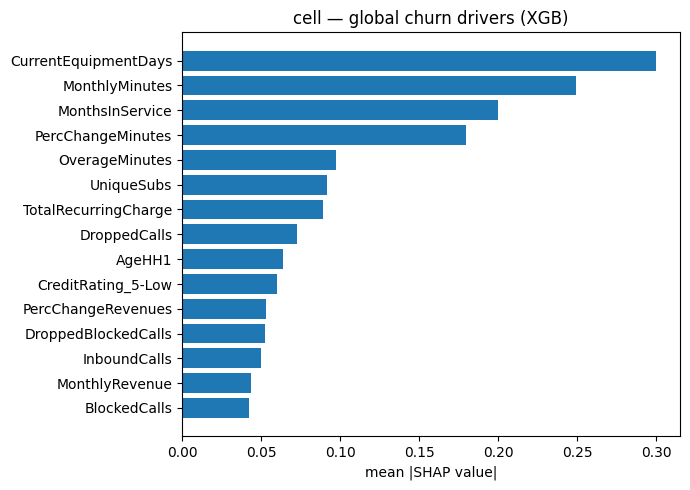

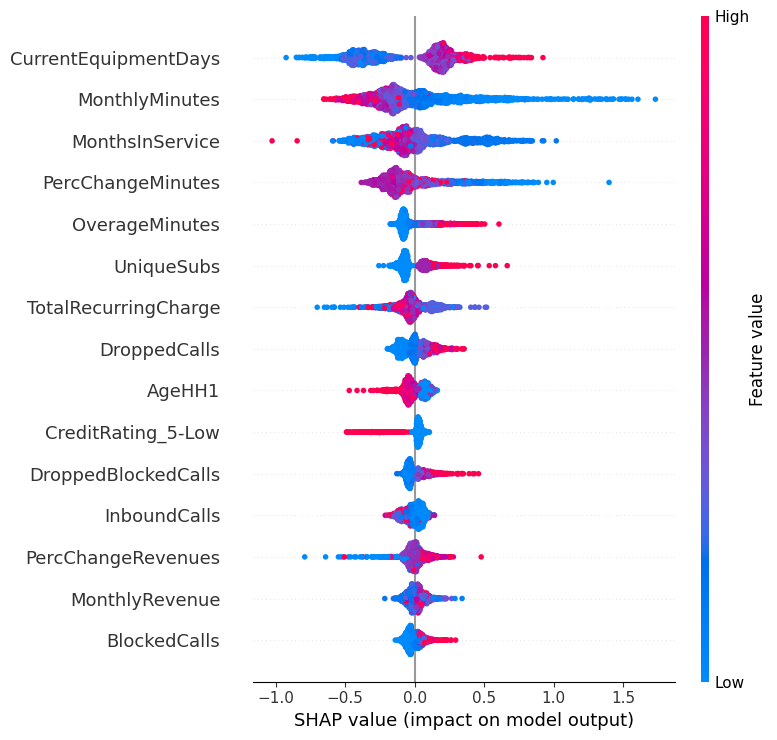

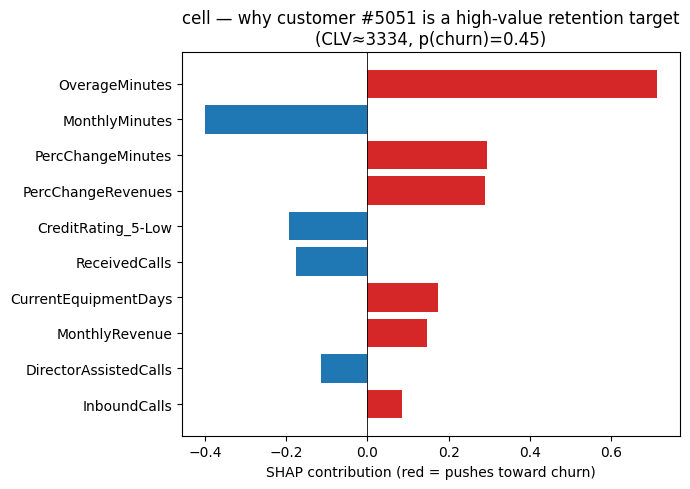

cell: local example customer #5051 | CLV≈3334 | p=0.448 | actual churn=0


In [5]:

# ===== CELL 5: run for both datasets =====
S_maven = get_shap("maven"); global_importance(S_maven); local_explanation(S_maven)
S_cell  = get_shap("cell");  global_importance(S_cell);  local_explanation(S_cell)
 


===== Maven actual churn-category distribution (churned customers) =====
Churn Category
Competitor         841
Dissatisfaction    321
Attitude           314
Price              211
Other              182


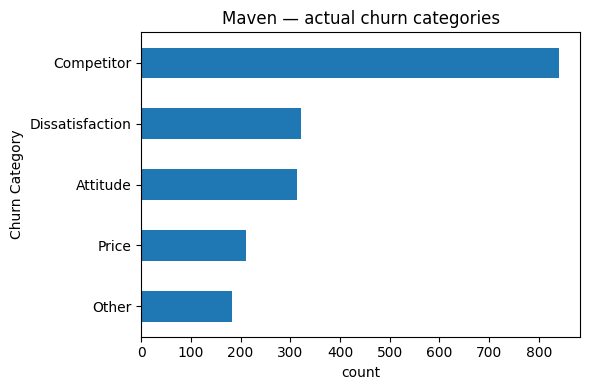


Validation narrative: check that top SHAP drivers (e.g. Contract, Tenure,
Monthly Charge, Internet Type) map onto the dominant real reasons
(Competitor / Dissatisfaction / Price) — strengthens trust in targeting.


In [6]:

# ===== CELL 6: qualitative validation vs actual churn reasons (Maven) =====
cr = pd.read_csv(f"{SPLIT_DIR}/maven_churn_reason.csv")
cat = cr["Churn Category"].dropna().value_counts()
print("\n===== Maven actual churn-category distribution (churned customers) =====")
print(cat.to_string())
plt.figure(figsize=(6, 4))
cat.iloc[::-1].plot(kind="barh")
plt.xlabel("count"); plt.title("Maven — actual churn categories")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_churn_categories.png", dpi=200); plt.show()
print("\nValidation narrative: check that top SHAP drivers (e.g. Contract, Tenure,\n"
      "Monthly Charge, Internet Type) map onto the dominant real reasons\n"
      "(Competitor / Dissatisfaction / Price) — strengthens trust in targeting.")
 
# ============================================================================
# DONE. Figures + importance tables saved. This is the last experiment notebook.
# Full evidence now in hand: baseline, imbalance, calibration, profit, SHAP.
# Next: assemble results tables/figures for the manuscript, then writing.
# ============================================================================